<a href="https://colab.research.google.com/github/rachmadnanda/MachineLearning2026/blob/main/DBScanCosine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import time
import tracemalloc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Library siap.")

Library siap.


In [2]:
df = pd.read_csv('dataset_properti.csv')
print("Shape awal:", df.shape)
df.head()

Shape awal: (1530, 8)


,id_properti,lokasi,luas_m2,jumlah_kamar,jumlah_kamar_mandi,usia_bangunan,harga,kategori_harga
0,PROP0655,Tangerang,30.0,3,3.0,33.0,203754275,Murah
1,PROP0077,Bekasi,122.0,5,4.0,19.0,1058031695,Murah
2,PROP0317,Bekasi,142.8,1,1.0,9.0,1335792780,Mahal
3,PROP1348,Bekasi,152.6,4,3.0,6.0,1613770786,Mahal
4,PROP0572,Depok,61.2,1,1.0,9.0,522156222,Murah


In [3]:
# ============================================
# PREPROCESSING UNIVERSAL (identik)
# ============================================

df = df.drop(columns=['id_properti'])

before = len(df)
df = df.drop_duplicates()
print(f"[1] Hapus duplikat       : {before} -> {len(df)}")

df['luas_m2'] = df['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
df['luas_m2'] = pd.to_numeric(df['luas_m2'], errors='coerce')

df['lokasi'] = df['lokasi'].str.strip().str.title()
df['lokasi'] = df['lokasi'].replace({'Jak. Utara': 'Jakarta Utara',
                                      'Jak. Selatan': 'Jakarta Selatan'})

numeric_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
                'usia_bangunan', 'harga']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
print(f"[2] Missing values diisi  : {df[numeric_cols].isnull().sum().sum()} tersisa")

before = len(df)
df = df[df['harga'] < 100_000_000_000]
df = df[df['luas_m2'] < 1000]
print(f"[3] Hapus outlier ekstrem : {before} -> {len(df)}")

df = df.reset_index(drop=True)

FEATURES = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
            'usia_bangunan', 'harga']
X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"[4] Data siap clustering  : {X_scaled.shape}")
print(f"[5] Fitur                 : {FEATURES}")

[1] Hapus duplikat       : 1530 -> 1500
[2] Missing values diisi  : 0 tersisa
[3] Hapus outlier ekstrem : 1500 -> 1498
[4] Data siap clustering  : (1498, 5)
[5] Fitur                 : ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']


min_samples = 10


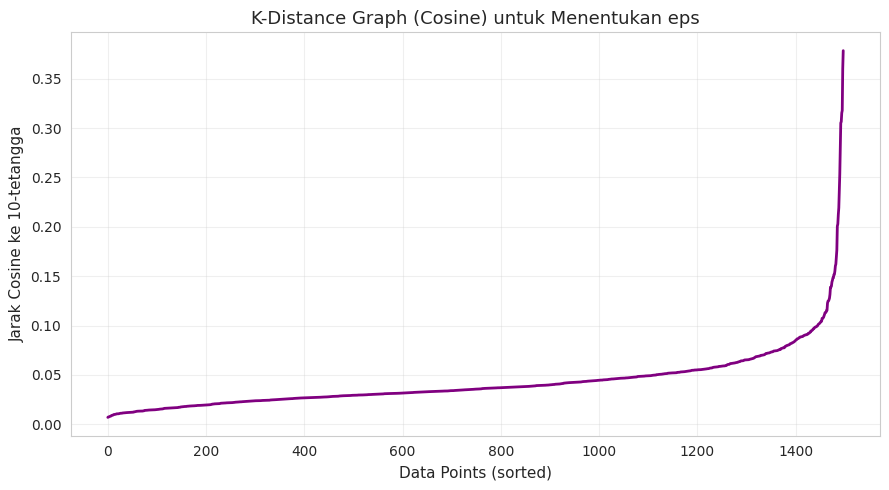


Kandidat eps berdasarkan persentil:
  Persentil 85: 0.0619
  Persentil 90: 0.0724
  Persentil 92: 0.0776
  Persentil 95: 0.0907
  Persentil 97: 0.1043


In [4]:
MIN_SAMPLES = 2 * len(FEATURES)
print(f"min_samples = {MIN_SAMPLES}")

# Hitung jarak cosine ke k-tetangga
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='cosine')
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

# Plot
plt.figure(figsize=(9, 5))
plt.plot(distances, color='purple', linewidth=2)
plt.xlabel('Data Points (sorted)', fontsize=11)
plt.ylabel(f'Jarak Cosine ke {MIN_SAMPLES}-tetangga', fontsize=11)
plt.title('K-Distance Graph (Cosine) untuk Menentukan eps', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKandidat eps berdasarkan persentil:")
for p in [85, 90, 92, 95, 97]:
    print(f"  Persentil {p}: {np.percentile(distances, p):.4f}")

In [5]:
# ============================================
# PARAMETER (sesuaikan dari k-distance graph)
# ============================================
EPS_VALUE = 0.1
MIN_SAMPLES = 2 * len(FEATURES)

# Tracking
tracemalloc.start()
start_time = time.time()

# Training dengan metric cosine
dbscan = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES, metric='cosine')
labels = dbscan.fit_predict(X_scaled)

exec_time = time.time() - start_time
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

df['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("="*55)
print("HASIL DBSCAN (COSINE)")
print("="*55)
print(f"eps                  : {EPS_VALUE}")
print(f"min_samples          : {MIN_SAMPLES}")
print(f"Jumlah cluster       : {n_clusters}")
print(f"Jumlah noise/outlier : {n_noise} ({n_noise/len(df)*100:.2f}%)")
print(f"Waktu eksekusi       : {exec_time:.4f} detik")
print(f"Peak memory          : {peak/1024:.2f} KB")
print("\nDistribusi cluster:")
print(df['cluster'].value_counts().sort_index())

HASIL DBSCAN (COSINE)
eps                  : 0.1
min_samples          : 10
Jumlah cluster       : 1
Jumlah noise/outlier : 17 (1.13%)
Waktu eksekusi       : 0.1039 detik
Peak memory          : 35189.41 KB

Distribusi cluster:
cluster
-1      17
 0    1481
Name: count, dtype: int64


In [6]:
cluster_only = df[df['cluster'] != -1]

if len(cluster_only) > 0:
    print("Rata-rata fitur per cluster (tanpa noise):")
    print(cluster_only.groupby('cluster')[FEATURES].mean().round(2))
else:
    print("Tidak ada cluster terbentuk — semua data jadi noise.")

Rata-rata fitur per cluster (tanpa noise):
         luas_m2  jumlah_kamar  jumlah_kamar_mandi  usia_bangunan  \
cluster                                                             
0         111.26          2.95                2.51          19.56   

                harga  
cluster                
0        1.276355e+09  


In [7]:
print("\nDistribusi lokasi per cluster:")
print(pd.crosstab(df['cluster'], df['lokasi']))

print("\nDistribusi kategori harga per cluster:")
print(pd.crosstab(df['cluster'], df['kategori_harga']))


Distribusi lokasi per cluster:
lokasi   Bekasi  Bogor  Depok  Jakarta Selatan  Jakarta Utara  Tangerang
cluster                                                                 
-1            4      2      2                5              1          3
 0          263    266    245              220            242        245

Distribusi kategori harga per cluster:
kategori_harga  Mahal  Murah
cluster                     
-1                 12      5
 0                737    744


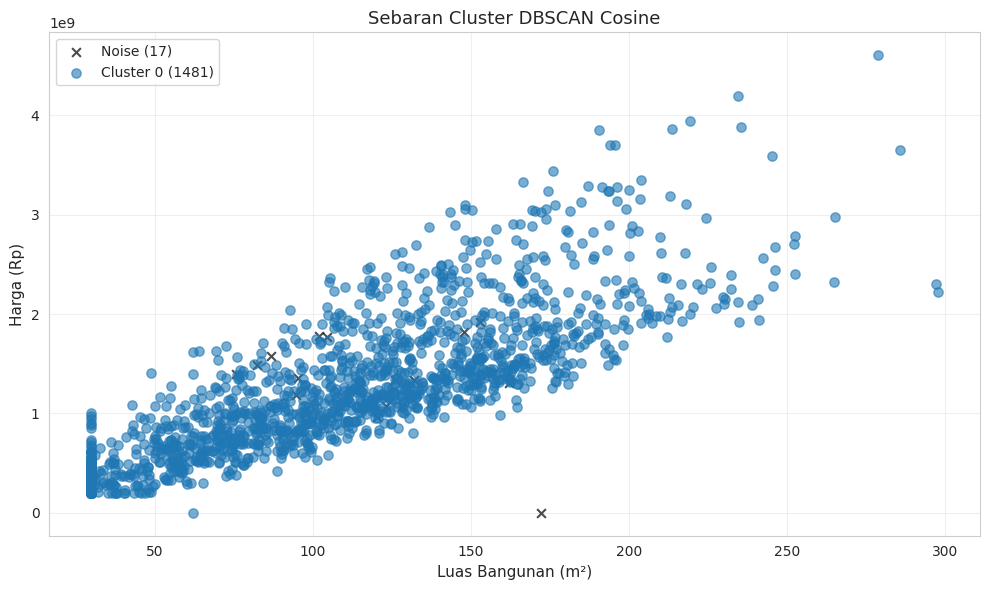

In [8]:
plt.figure(figsize=(10, 6))

for label in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == label]
    if label == -1:
        plt.scatter(subset['luas_m2'], subset['harga'],
                    c='black', marker='x', s=40, alpha=0.7,
                    label=f'Noise ({len(subset)})')
    else:
        plt.scatter(subset['luas_m2'], subset['harga'],
                    s=45, alpha=0.6, label=f'Cluster {label} ({len(subset)})')

plt.xlabel('Luas Bangunan (m²)', fontsize=11)
plt.ylabel('Harga (Rp)', fontsize=11)
plt.title('Sebaran Cluster DBSCAN Cosine', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

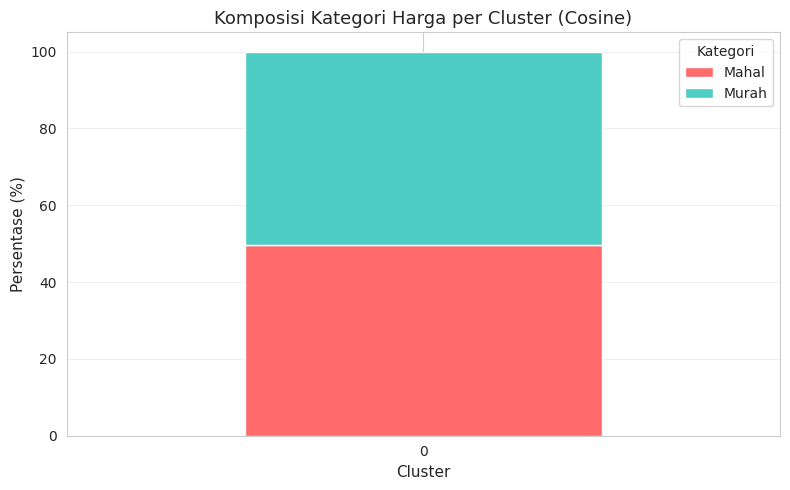


Persentase kategori harga per cluster (%):
kategori_harga  Mahal  Murah
cluster                     
0               49.76  50.24


In [9]:
if len(cluster_only) > 0:
    comp = pd.crosstab(cluster_only['cluster'],
                       cluster_only['kategori_harga'],
                       normalize='index') * 100

    comp.plot(kind='bar', stacked=True, figsize=(8, 5),
              color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
    plt.xlabel('Cluster', fontsize=11)
    plt.ylabel('Persentase (%)', fontsize=11)
    plt.title('Komposisi Kategori Harga per Cluster (Cosine)', fontsize=13)
    plt.legend(title='Kategori', loc='upper right')
    plt.xticks(rotation=0)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    print("\nPersentase kategori harga per cluster (%):")
    print(comp.round(2))
else:
    print("Tidak ada cluster untuk divisualisasikan.")

In [10]:
mask = df['cluster'] != -1

if len(set(df.loc[mask, 'cluster'])) > 1:
    sil_score = silhouette_score(X_scaled[mask],
                                  df.loc[mask, 'cluster'],
                                  metric='cosine')
    print(f"Silhouette Score (Cosine): {sil_score:.4f}")
else:
    sil_score = None
    print("Silhouette tidak dapat dihitung (cluster < 2)")

Silhouette tidak dapat dihitung (cluster < 2)


In [11]:
hasil_dbscan_cosine = {
    'Metode'              : 'DBSCAN',
    'Distance Metric'     : 'Cosine',
    'Jumlah Cluster'      : n_clusters,
    'Jumlah Noise'        : n_noise,
    'Waktu Eksekusi (s)'  : round(exec_time, 4),
    'Peak Memory (KB)'    : round(peak / 1024, 2),
    'Silhouette Score'    : round(sil_score, 4) if sil_score else None,
    'Parameter'           : f'eps={EPS_VALUE}, min_samples={MIN_SAMPLES}'
}

tabel = pd.DataFrame([hasil_dbscan_cosine])
print("="*60)
print("RINGKASAN METRIK — DBSCAN COSINE")
print("="*60)
tabel.T

RINGKASAN METRIK — DBSCAN COSINE


,0
Metode,DBSCAN
Distance Metric,Cosine
Jumlah Cluster,1
Jumlah Noise,17
Waktu Eksekusi (s),0.1039
Peak Memory (KB),35189.41
Silhouette Score,None
Parameter,"eps=0.1, min_samples=10"
